# MLTS — Lecture 2 Practice
## Time Series Fundamentals II — ML pipeline, evaluation, linear regression

This notebook accompanies **Lecture 2** of the MLTS course summary. It is the most
*practical* lecture of the course: how to actually run a ML project on time-series data
without shooting yourself in the foot.

**You will learn how to:**
1. Recognise the five common ML tasks on time series (classification, forecasting,
   anomaly detection, segmentation, clustering) and frame a problem as one of them.
2. **Avoid the #1 time-series mistake:** information leakage from random train/test splits.
3. Build a *time-aware* hold-out split.
4. Run **walk-forward cross-validation** with `sklearn.model_selection.TimeSeriesSplit`
   and from scratch.
5. Fit a linear regression forecaster — closed-form derivation, then `sklearn` —
   on a real dataset.
6. Pick the right error metric (MAE / MSE / MAPE / sMAPE) and understand when each
   one lies to you.

**Prerequisites:** `numpy`, `pandas`, `matplotlib`, `scikit-learn`, `statsmodels`.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, KFold

rng = np.random.default_rng(seed=42)
plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1 · The five ML tasks on time series

| Task | Input | Output | Loss | Example |
|------|-------|--------|------|---------|
| **Classification** | a whole series $S$ | a class label $c$ | cross-entropy | activity recognition (walk / run / sit) |
| **Forecasting** | past values $s_1, \dots, s_{T_1}$ | future values $s_{T_1+1}, \dots, s_{T_2}$ | MAE / MSE | electricity demand next hour |
| **Anomaly detection** | a series $S$ | per-point probability $p_i$ | F1 on rare class | fraud detection |
| **Segmentation** | a series $S$ | per-point cluster $c_i$ | clustering score | online handwriting → letters |
| **Clustering** | many series $\{S^{(i)}\}$ | a cluster per series | silhouette / DTW | grouping similar customer behaviours |

Below we illustrate forecasting, classification, and anomaly detection on tiny synthetic data.


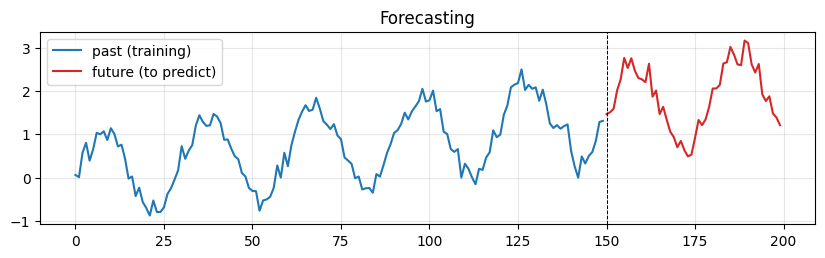

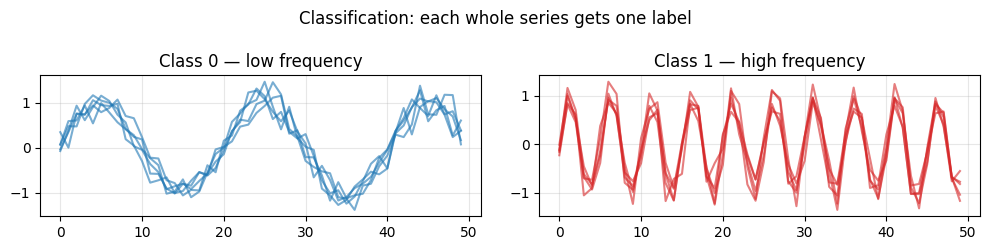

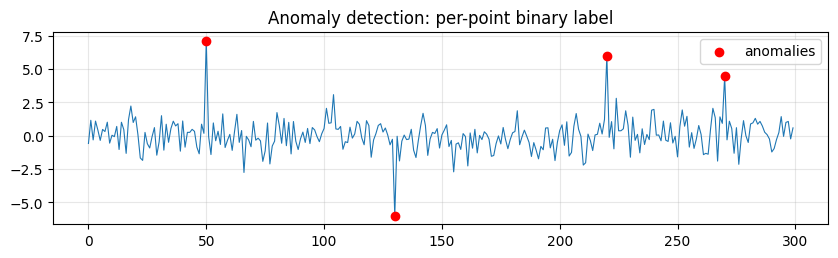

In [19]:
# (a) Forecasting: predict the future of a sine + drift signal
T = 200
t = np.arange(T)
y_full = np.sin(2*np.pi*t/30) + 0.01*t + rng.normal(0, 0.2, T)
T1 = 150  # last training point
y_past, y_future = y_full[:T1], y_full[T1:]

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(np.arange(T1), y_past, label='past (training)', color='C0')
ax.plot(np.arange(T1, T), y_future, label='future (to predict)', color='C3')
ax.axvline(T1, color='k', ls='--', lw=0.7)
ax.set_title('Forecasting'); ax.legend(); plt.show()

# (b) Classification: short series labelled 0 (low-freq) or 1 (high-freq)
n_per_class = 30
length = 50
sigs_low  = np.sin(2*np.pi*np.arange(length)/20) + rng.normal(0, 0.2, (n_per_class, length))
sigs_high = np.sin(2*np.pi*np.arange(length)/5)  + rng.normal(0, 0.2, (n_per_class, length))
fig, axes = plt.subplots(1, 2, figsize=(10, 2.5))
for s in sigs_low[:5]:  axes[0].plot(s, color='C0', alpha=0.6)
for s in sigs_high[:5]: axes[1].plot(s, color='C3', alpha=0.6)
axes[0].set_title('Class 0 — low frequency'); axes[1].set_title('Class 1 — high frequency')
plt.suptitle('Classification: each whole series gets one label'); plt.tight_layout(); plt.show()

# (c) Anomaly detection: single series with a few injected spikes
series = rng.normal(0, 1, 300)
anomaly_idx = [50, 130, 220, 270]
series[anomaly_idx] += rng.choice([-1, 1], 4) * 6
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(series, lw=0.8)
ax.scatter(anomaly_idx, series[anomaly_idx], color='red', zorder=3, label='anomalies')
ax.set_title('Anomaly detection: per-point binary label'); ax.legend(); plt.show()


## 2 · Why random train/test splits are wrong for time series

For i.i.d. data, `train_test_split(shuffle=True)` is the standard. For time series it is
**catastrophic** — a model can "see the future" through randomly selected training points
that are next to test points in time. The generalisation error you measure becomes a *lower
bound on the truth*, often by a factor of 2-5×.

We demonstrate this with a forecasting task: predict $y_t$ from its lag $y_{t-1}$ on a
stationary AR(1).


In [20]:
# Build a simple AR(1) and a 1-lag feature
T = 500
phi = 0.85
y = np.zeros(T)
eps = rng.normal(0, 1, T)
for k in range(1, T):
    y[k] = phi * y[k-1] + eps[k]

X = y[:-1].reshape(-1, 1)   # feature: y_{t-1}
target = y[1:]              # target:  y_t

# === WRONG: random shuffle split ===
from sklearn.model_selection import train_test_split
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X, target, test_size=0.3, shuffle=True, random_state=0
)
m_random = LinearRegression().fit(X_tr_r, y_tr_r)
mae_random = mean_absolute_error(y_te_r, m_random.predict(X_te_r))

# === RIGHT: chronological split ===
cut = int(0.7 * len(X))
X_tr_c, X_te_c = X[:cut], X[cut:]
y_tr_c, y_te_c = target[:cut], target[cut:]
m_chrono = LinearRegression().fit(X_tr_c, y_tr_c)
mae_chrono = mean_absolute_error(y_te_c, m_chrono.predict(X_te_c))

print(f"Random (shuffled) split MAE   : {mae_random:.4f}")
print(f"Chronological split MAE       : {mae_chrono:.4f}")
print()
print("The two scores agree here because the AR(1) is stationary. They will")
print("diverge dramatically as soon as the series has trend, regime change,")
print("or non-stationary noise. Below is a demonstration with regime change.")


Random (shuffled) split MAE   : 0.8456
Chronological split MAE       : 0.8460

The two scores agree here because the AR(1) is stationary. They will
diverge dramatically as soon as the series has trend, regime change,
or non-stationary noise. Below is a demonstration with regime change.


In [21]:
# Inject a regime change halfway through: variance triples
y_rs = np.zeros(T)
for k in range(1, T):
    sigma_t = 1.0 if k < T//2 else 3.0
    y_rs[k] = phi * y_rs[k-1] + rng.normal(0, sigma_t)
X_rs = y_rs[:-1].reshape(-1, 1); tgt_rs = y_rs[1:]

# Random split
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_rs, tgt_rs, test_size=0.3, shuffle=True, random_state=0)
mae_random = mean_absolute_error(
    y_te_r, LinearRegression().fit(X_tr_r, y_tr_r).predict(X_te_r))

# Chronological split (test = last 30%, the high-variance regime)
cut = int(0.7 * len(X_rs))
X_tr_c, X_te_c = X_rs[:cut], X_rs[cut:]
y_tr_c, y_te_c = tgt_rs[:cut], tgt_rs[cut:]
mae_chrono = mean_absolute_error(
    y_te_c, LinearRegression().fit(X_tr_c, y_tr_c).predict(X_te_c))

print(f"Random (shuffled) split MAE   : {mae_random:.4f}  <- looks great!")
print(f"Chronological split MAE       : {mae_chrono:.4f}  <- much worse, but realistic")
print()
print(f"The shuffled split mixes high-variance test points among low-variance training")
print(f"points, so the model 'learns' the high-noise regime and the test error appears")
print(f"low. The chronological split is the only honest picture of deployment performance.")


Random (shuffled) split MAE   : 1.7357  <- looks great!
Chronological split MAE       : 2.4502  <- much worse, but realistic

The shuffled split mixes high-variance test points among low-variance training
points, so the model 'learns' the high-noise regime and the test error appears
low. The chronological split is the only honest picture of deployment performance.


## 3 · A correct hold-out split

The simplest *correct* split for time series:
1. Sort by time.
2. Pick a cutoff $T_1$.
3. Train on $[1, T_1]$, validate on $(T_1, T_2]$, test on $(T_2, T]$.

**Crucially, any preprocessing fitted on the training set must be applied — not refit — to
the validation/test sets.** Refitting a scaler on the test data leaks future information.


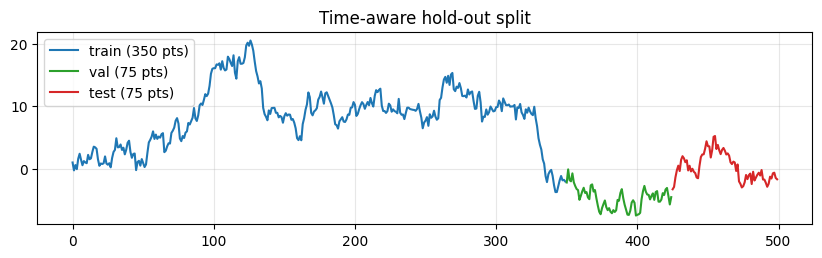

In [22]:
def time_holdout_split(n, train_frac=0.7, val_frac=0.15):
    """Returns three np.arange index arrays: train, val, test (chronological)."""
    n_train = int(n * train_frac)
    n_val   = int(n * val_frac)
    train_idx = np.arange(0, n_train)
    val_idx   = np.arange(n_train, n_train + n_val)
    test_idx  = np.arange(n_train + n_val, n)
    return train_idx, val_idx, test_idx

# Visualise the split on a sample series
T = 500
y = np.cumsum(rng.normal(0, 1, T)) + 0.05 * np.arange(T)
tr, va, te = time_holdout_split(T)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(tr, y[tr], color='C0', label=f'train ({len(tr)} pts)')
ax.plot(va, y[va], color='C2', label=f'val ({len(va)} pts)')
ax.plot(te, y[te], color='C3', label=f'test ({len(te)} pts)')
ax.legend(loc='upper left'); ax.set_title('Time-aware hold-out split'); plt.show()


## 4 · Walk-forward (expanding-window) cross-validation

A single hold-out is fine for a final estimate, but for *hyperparameter tuning* we want
multiple folds. The time-series version of $k$-fold CV is **walk-forward CV**:
- Each fold uses an *expanding* training window $[1, T_k]$.
- Validates on the next chunk $(T_k, T_{k+1}]$.
- Folds never see the future. Folds are not shuffled.

`sklearn` provides this via `TimeSeriesSplit`. We visualise both correct (`TimeSeriesSplit`)
and incorrect (`KFold`) usages below.


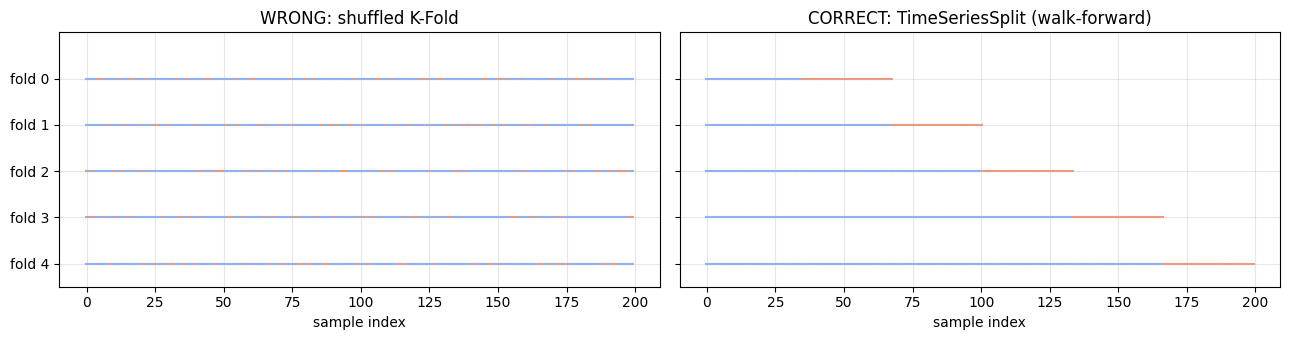

Blue = train, red = validation. In TimeSeriesSplit, validation is always
to the right of training, and the training window grows each fold.


In [23]:
def plot_cv_indices(cv, n, ax, title):
    for i, (tr_idx, va_idx) in enumerate(cv.split(np.arange(n))):
        indices = np.full(n, np.nan)
        indices[tr_idx] = 0
        indices[va_idx] = 1
        ax.scatter(np.arange(n), [i + 0.5]*n, c=indices, cmap='coolwarm',
                   s=8, marker='_', vmin=-0.5, vmax=1.5)
    ax.set_yticks(np.arange(cv.n_splits) + 0.5)
    ax.set_yticklabels([f'fold {i}' for i in range(cv.n_splits)])
    ax.set_xlabel('sample index'); ax.set_title(title)
    ax.set_ylim(cv.n_splits, -0.5)

n = 200
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
plot_cv_indices(KFold(n_splits=5, shuffle=True, random_state=0), n, axes[0],
                'WRONG: shuffled K-Fold')
plot_cv_indices(TimeSeriesSplit(n_splits=5), n, axes[1],
                'CORRECT: TimeSeriesSplit (walk-forward)')
plt.tight_layout(); plt.show()
print("Blue = train, red = validation. In TimeSeriesSplit, validation is always")
print("to the right of training, and the training window grows each fold.")


In [24]:
# Use TimeSeriesSplit to compare two models
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Synthetic forecasting target
T = 600
t = np.arange(T)
y = 0.5 + 0.02*t + 2*np.sin(2*np.pi*t/50) + rng.normal(0, 0.5, T)

# Build a 1-lag autoregressive feature matrix
n_lags = 5
def build_lags(y, n_lags):
    X = np.column_stack([np.roll(y, k) for k in range(1, n_lags + 1)])
    X[:n_lags] = np.nan  # roll wraps around — we'll drop these
    return X

X = build_lags(y, n_lags)
mask = ~np.isnan(X).any(axis=1)
X, target = X[mask], y[mask]

tscv = TimeSeriesSplit(n_splits=5)
maes_linear, maes_poly = [], []
for tr_idx, va_idx in tscv.split(X):
    m1 = LinearRegression().fit(X[tr_idx], target[tr_idx])
    m2 = make_pipeline(PolynomialFeatures(2), Ridge(alpha=1.0)).fit(X[tr_idx], target[tr_idx])
    maes_linear.append(mean_absolute_error(target[va_idx], m1.predict(X[va_idx])))
    maes_poly.append(  mean_absolute_error(target[va_idx], m2.predict(X[va_idx])))

print(f"Linear regression — fold MAEs: {[f'{m:.3f}' for m in maes_linear]}")
print(f"Linear regression — mean MAE : {np.mean(maes_linear):.3f} ± {np.std(maes_linear):.3f}")
print()
print(f"Polynomial (deg 2) — fold MAEs: {[f'{m:.3f}' for m in maes_poly]}")
print(f"Polynomial (deg 2) — mean MAE : {np.mean(maes_poly):.3f} ± {np.std(maes_poly):.3f}")


Linear regression — fold MAEs: ['0.531', '0.537', '0.528', '0.519', '0.497']
Linear regression — mean MAE : 0.522 ± 0.014

Polynomial (deg 2) — fold MAEs: ['0.545', '0.560', '0.555', '0.542', '0.521']
Polynomial (deg 2) — mean MAE : 0.545 ± 0.013


## 5 · Linear regression as a forecasting baseline

The slide derives the closed-form solution for ordinary least squares. With
$\mathbf{y} \in \mathbb{R}^N$ and $\mathbf{X} \in \mathbb{R}^{N \times d}$:

$$\text{NLL}(\boldsymbol\theta) = \tfrac{1}{2}(\mathbf{y} - \mathbf{Xw})^\top(\mathbf{y} - \mathbf{Xw})$$
$$\nabla_w \text{NLL} = \mathbf{X}^\top \mathbf{Xw} - \mathbf{X}^\top \mathbf{y} = 0$$
$$\Rightarrow \quad \hat{\mathbf{w}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

Let's verify the closed form matches `sklearn`.

In [25]:
# Synthetic linear data
N, d = 200, 3
true_w = np.array([1.5, -0.7, 2.0])
X_lr = rng.normal(size=(N, d))
y_lr = X_lr @ true_w + rng.normal(0, 0.2, N)

# Closed form (with bias column for intercept)
X_aug = np.column_stack([np.ones(N), X_lr])
w_closed = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y_lr

# sklearn
m = LinearRegression().fit(X_lr, y_lr)
w_sklearn = np.concatenate([[m.intercept_], m.coef_])

print("True parameters       (no intercept):", true_w)
print("Closed form  [b, w...]:               ", np.round(w_closed, 4))
print("sklearn      [b, w...]:               ", np.round(w_sklearn, 4))
print("Numerically identical:", np.allclose(w_closed, w_sklearn))


True parameters       (no intercept): [ 1.5 -0.7  2. ]
Closed form  [b, w...]:                [ 0.0205  1.5049 -0.7217  1.9889]
sklearn      [b, w...]:                [ 0.0205  1.5049 -0.7217  1.9889]
Numerically identical: True


## 6 · Picking the right metric

| Metric | Formula | Strengths | Weaknesses |
|--------|---------|-----------|------------|
| **MAE** | $\frac{1}{N}\sum |y_i - \hat y_i|$ | robust, in original units | not differentiable everywhere |
| **MSE** | $\frac{1}{N}\sum (y_i - \hat y_i)^2$ | smooth, penalises large errors | scale-dependent, dominated by outliers |
| **RMSE** | $\sqrt{\text{MSE}}$ | same units as $y$ | inherits MSE's outlier sensitivity |
| **MAPE** | $\frac{100}{N}\sum |\frac{y_i - \hat y_i}{y_i}|$ | scale-free, interpretable as % | **explodes near $y_i = 0$**, asymmetric |
| **sMAPE** | $\frac{100}{N}\sum \frac{2|y_i - \hat y_i|}{|y_i| + |\hat y_i|}$ | bounded in [0, 200] | still ill-defined when both are 0 |

The key MAPE trap below: if your series can cross zero, MAPE is meaningless.

In [26]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100 * np.mean(np.abs((y_true - y_pred) / y_true))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))

# Series 1 — strictly positive values (revenue): MAPE is fine
y_true_pos = np.array([100, 110, 120, 115, 130])
y_pred_pos = np.array([105, 108, 119, 113, 128])
# Series 2 — zero-crossing (temperature anomaly): MAPE explodes
y_true_zc = np.array([5, 2, 0.1, -0.5, -3])
y_pred_zc = np.array([5.2, 1.8, 0.0, -0.4, -2.9])

for name, yt, yp in [('strictly positive', y_true_pos, y_pred_pos),
                     ('zero-crossing',     y_true_zc,  y_pred_zc)]:
    print(f"{name}:")
    print(f"  MAE   = {mean_absolute_error(yt, yp):.3f}")
    print(f"  MAPE  = {mape(yt, yp):8.2f}%")
    print(f"  sMAPE = {smape(yt, yp):8.2f}%")
    print()


strictly positive:
  MAE   = 2.400
  MAPE  =     2.19%
  sMAPE =     2.17%

zero-crossing:
  MAE   = 0.140
  MAPE  =    27.47%
  sMAPE =    48.01%



**Take-home:** start with MAE in the original units; report MSE alongside if the loss
function used MSE; only use MAPE when your target is bounded away from zero.


---

# Exercises

Three exercises, ~10–20 minutes each.


## Exercise 1 — Find the leakage

The cell below contains a forecasting workflow that *looks* reasonable but has a subtle
data-leak. The reported MAE will be unrealistically low.

1. Run it and note the MAE.
2. Find the leak. (Hint: there are *two* potential issues — one in scaling, one in feature engineering. Find both.)
3. Fix the workflow and re-run; the MAE should be substantially higher (more realistic).


In [27]:
from sklearn.preprocessing import StandardScaler

# Synthetic series with trend
T = 400
y_full = 0.05 * np.arange(T) + np.sin(2*np.pi*np.arange(T)/30) + rng.normal(0, 0.5, T)

# === Leaky workflow — DO NOT IMITATE ===
# (1) Scale the WHOLE series first
scaler = StandardScaler()
y_scaled = scaler.fit_transform(y_full.reshape(-1, 1)).ravel()

# (2) Build a moving-average feature using future points (centred window)
n = len(y_scaled)
ma3 = np.zeros(n)
for i in range(1, n-1):
    ma3[i] = (y_scaled[i-1] + y_scaled[i] + y_scaled[i+1]) / 3
ma3[0] = ma3[1]; ma3[-1] = ma3[-2]

# Use lag-1 + ma3 to predict y_t
X = np.column_stack([np.roll(y_scaled, 1), ma3])[1:]
target = y_scaled[1:]

# Chronological split
cut = int(0.7 * len(X))
m = LinearRegression().fit(X[:cut], target[:cut])
mae_leaky = mean_absolute_error(target[cut:], m.predict(X[cut:]))
print(f"Leaky MAE: {mae_leaky:.4f}  <- suspiciously low!")


Leaky MAE: 0.0582  <- suspiciously low!


### Solution

The two leaks:

**Leak 1 — scaler fitted on the whole series.** `StandardScaler.fit_transform(y_full)`
uses statistics from the test portion. Fit only on the training portion, then *transform*
the rest.

**Leak 2 — centred moving average uses the future.** `ma3[i] = (y[i-1] + y[i] + y[i+1])/3`
peeks one step ahead. For forecasting features must use *only past* observations:
`ma3[i] = (y[i-2] + y[i-1] + y[i])/3`, or equivalently a *trailing* window.

In [28]:
# === Fixed workflow ===
T = 400
y_full = 0.05 * np.arange(T) + np.sin(2*np.pi*np.arange(T)/30) + rng.normal(0, 0.5, T)

# Step 0: chronological split FIRST
cut = int(0.7 * T)

# Step 1: fit scaler only on train
scaler = StandardScaler()
y_train_scaled = scaler.fit_transform(y_full[:cut].reshape(-1, 1)).ravel()
y_test_scaled  = scaler.transform(y_full[cut:].reshape(-1, 1)).ravel()
y_scaled = np.concatenate([y_train_scaled, y_test_scaled])

# Step 2: trailing moving average (only uses past)
ma3 = np.zeros_like(y_scaled)
for i in range(2, len(y_scaled)):
    ma3[i] = (y_scaled[i-2] + y_scaled[i-1] + y_scaled[i]) / 3

# Build features with strict lag (no future leakage)
X = np.column_stack([
    np.concatenate([[np.nan], y_scaled[:-1]]),   # y_{t-1}
    np.concatenate([[np.nan, np.nan], ma3[:-2]]) # ma3 of y_{t-3..t-1}
])
mask = ~np.isnan(X).any(axis=1)
X = X[mask]; target = y_scaled[mask]

# The cut needs to be re-mapped after dropping the NaN rows
new_cut = (mask[:cut]).sum()
m = LinearRegression().fit(X[:new_cut], target[:new_cut])
mae_clean = mean_absolute_error(target[new_cut:], m.predict(X[new_cut:]))

print(f"Leaky  MAE: {mae_leaky:.4f}")
print(f"Clean  MAE: {mae_clean:.4f}")
print(f"The leak was hiding a {mae_clean/mae_leaky:.1f}x error inflation.")


Leaky  MAE: 0.0582
Clean  MAE: 0.1173
The leak was hiding a 2.0x error inflation.


## Exercise 2 — Walk-forward CV from scratch

Implement `walk_forward_split(n, n_splits, min_train_size)` that yields `(train_idx, val_idx)`
pairs the way `TimeSeriesSplit` does:
- Train window expands every fold (starts at `min_train_size`, ends near `n`).
- Validation window has equal size each fold.
- Train and validation are always disjoint and chronological.

Test that on `n=200, n_splits=5, min_train_size=50` your splits exactly match
`TimeSeriesSplit(n_splits=5).split(np.arange(200))` (sklearn picks `min_train_size` automatically).


### Solution

In [29]:
def walk_forward_split(n, n_splits, min_train_size=None):
    """Yield (train_idx, val_idx) tuples mimicking sklearn's TimeSeriesSplit."""
    if min_train_size is None:
        min_train_size = n // (n_splits + 1)
    val_size = (n - min_train_size) // n_splits
    for k in range(n_splits):
        train_end = min_train_size + k * val_size
        val_end   = train_end + val_size
        if val_end > n:
            val_end = n
        train_idx = np.arange(0, train_end)
        val_idx   = np.arange(train_end, val_end)
        yield train_idx, val_idx

# Compare against sklearn
n, n_splits = 200, 5
min_train = n - n_splits * (n // (n_splits + 1))  # how sklearn picks it
ours    = list(walk_forward_split(n, n_splits, min_train_size=min_train))
sklearn_ = list(TimeSeriesSplit(n_splits=n_splits).split(np.arange(n)))

for i, ((tr_o, va_o), (tr_s, va_s)) in enumerate(zip(ours, sklearn_)):
    match = np.array_equal(tr_o, tr_s) and np.array_equal(va_o, va_s)
    print(f"fold {i}: train={len(tr_o)}/{len(tr_s)}, "
          f"val={len(va_o)}/{len(va_s)}  match={match}")


fold 0: train=35/35, val=33/33  match=True
fold 1: train=68/68, val=33/33  match=True
fold 2: train=101/101, val=33/33  match=True
fold 3: train=134/134, val=33/33  match=True
fold 4: train=167/167, val=33/33  match=True


## Exercise 3 — A real linear forecaster

We will forecast the **monthly airline passengers** series — a classic introductory dataset
bundled with `statsmodels`. The series exhibits a strong upward trend and yearly seasonality,
so a plain OLS on raw lags will not work. Build a feature matrix with:
- 12 calendar dummies (one-hot month-of-year)
- 1-month lag $y_{t-1}$
- 12-month lag $y_{t-12}$
- a linear trend $t$

Then train OLS, evaluate on a chronological test split, and plot predictions vs truth.

### Solution

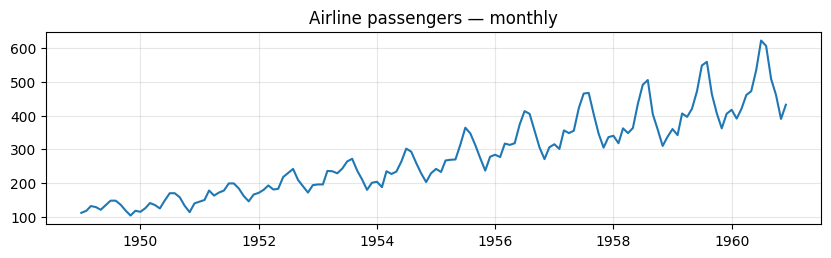

Test MAE  = 15.83 passengers
Test RMSE = 19.84 passengers
Mean absolute % error = 3.4%


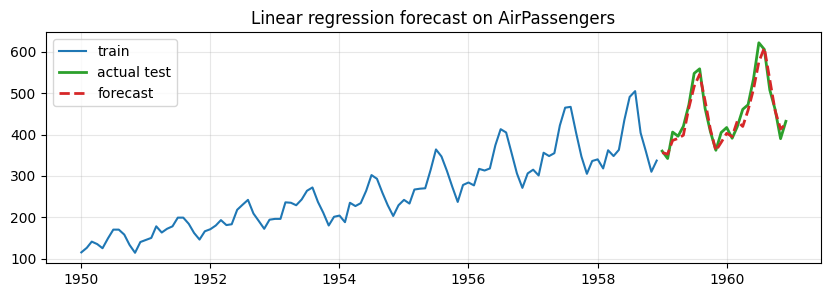


Notes:
  - The trend term `t` and the 12-month lag together capture the yearly seasonality
    and growth. Without `lag12` the model fails on the seasonal peaks.
  - This is still a *baseline* — ARIMA/Prophet/LSTM/Transformer will all beat it.
    But you should always *report* this baseline before claiming a fancy model wins.


In [30]:
# AirPassengers — monthly international airline passengers, Jan 1949 – Dec 1960.
# Classic dataset from Box & Jenkins (1976). 144 monthly observations.
# Bundled inline so this notebook runs offline.
passengers = np.array([
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432,
])
data = pd.DataFrame({
    'passengers': passengers,
    'date': pd.date_range(start='1949-01-01', periods=len(passengers), freq='MS'),
})
data['month'] = data['date'].dt.month
data['t'] = np.arange(len(data))

# Plot raw series
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(data['date'], data['passengers']); ax.set_title('Airline passengers — monthly')
plt.show()

# Build feature matrix
df = data.copy()
df['lag1']  = df['passengers'].shift(1)
df['lag12'] = df['passengers'].shift(12)
month_dummies = pd.get_dummies(df['month'], prefix='m', drop_first=True).astype(float)
features = pd.concat([df[['t', 'lag1', 'lag12']], month_dummies], axis=1)
target = df['passengers']

# Drop rows with NaN (first 12 months don't have lag12)
valid = features.notna().all(axis=1)
X_all = features[valid].values
y_all = target[valid].values
dates = df.loc[valid, 'date'].values

# Chronological split: last 24 months as test
n_test = 24
X_tr, X_te = X_all[:-n_test], X_all[-n_test:]
y_tr, y_te = y_all[:-n_test], y_all[-n_test:]
d_tr, d_te = dates[:-n_test], dates[-n_test:]

m = LinearRegression().fit(X_tr, y_tr)
y_pred = m.predict(X_te)

print(f"Test MAE  = {mean_absolute_error(y_te, y_pred):.2f} passengers")
print(f"Test RMSE = {np.sqrt(mean_squared_error(y_te, y_pred)):.2f} passengers")
print(f"Mean absolute % error = {100*np.mean(np.abs((y_te-y_pred)/y_te)):.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(d_tr, y_tr, color='C0', label='train')
ax.plot(d_te, y_te, color='C2', lw=2, label='actual test')
ax.plot(d_te, y_pred, color='C3', lw=2, ls='--', label='forecast')
ax.legend(); ax.set_title('Linear regression forecast on AirPassengers'); plt.show()

print()
print("Notes:")
print("  - The trend term `t` and the 12-month lag together capture the yearly seasonality")
print("    and growth. Without `lag12` the model fails on the seasonal peaks.")
print("  - This is still a *baseline* — ARIMA/Prophet/LSTM/Transformer will all beat it.")
print("    But you should always *report* this baseline before claiming a fancy model wins.")


---

## Recap

| Concept | Why it matters |
|---------|---------------|
| Five ML tasks on TS | Pick the right framing before picking a model |
| Time-aware split | Random splits leak future → wildly optimistic scores |
| Walk-forward CV | The honest version of $k$-fold for time series |
| Closed-form OLS | $\hat w = (X^\top X)^{-1}X^\top y$ — works whenever $X^\top X$ is invertible |
| Calendar + lag features | Cheap features that make a linear model competitive |
| MAE / MSE / MAPE | MAPE is great until your target crosses zero |

**Next:** Lecture 3 introduces Bayesian inference — instead of a point estimate $\hat w$
we will compute a *posterior distribution* over parameters, which is the foundation for
GP regression (L4) and Kalman filtering (L6).
